<a href="https://colab.research.google.com/github/sohelcr77/text_analysis_com_762/blob/main/text_analysis_s25013941.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Setup and Imports

In [4]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from textblob import TextBlob


## Load Data and Prepare Text

In [10]:

# Download dataset
path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")

print("Path to dataset files:", path)


# Load dataset
df = pd.read_csv(path + "/Reviews.csv", nrows=50000)

# Combine text
text = " ".join(df['Text'].astype(str))



Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
Path to dataset files: /kaggle/input/amazon-fine-food-reviews


## Word Cloud Generation

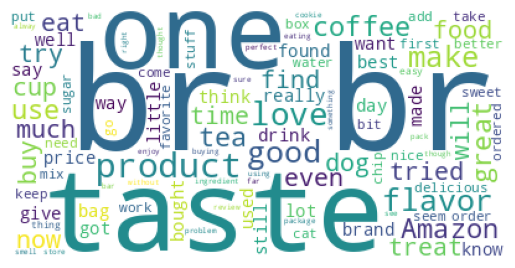

In [11]:
# WORD CLOUD
wc = WordCloud(stopwords=set(STOPWORDS),
               max_words=100,
               background_color="white").generate(text)

plt.imshow(wc); plt.axis("off"); plt.savefig("wordcloud.png")


## Sentiment Analysis

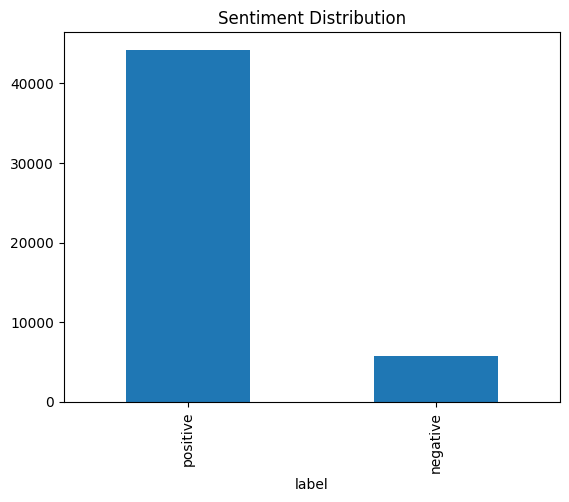

In [8]:

# SENTIMENT
df['sentiment'] = df['Text'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['label'] = df['sentiment'].apply(lambda x: 'positive' if x>0 else 'negative')

df['label'].value_counts().plot(kind='bar', title="Sentiment Distribution")
plt.savefig("sentiment_plot.png")


## Ratings Behavioral Pattern

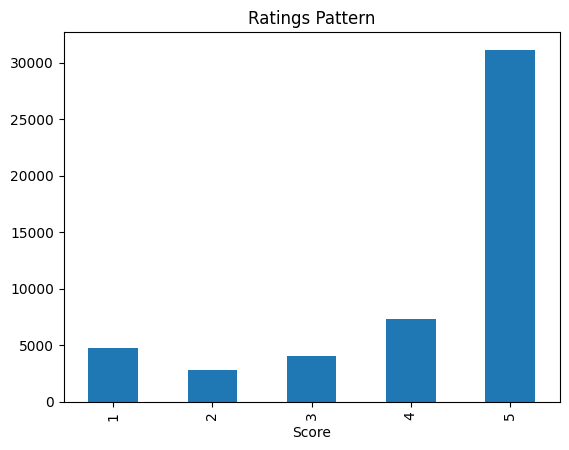

In [9]:



# BEHAVIOURAL PATTERN (ratings)
df['Score'].value_counts().sort_index().plot(kind='bar', title="Ratings Pattern")
plt.savefig("ratings_pattern.png")

# New Section